In [1]:

import xarray as xr
from gliderflightOG1 import plotters, tools
import numpy as np
import matplotlib.pyplot as plt
from gliderflightOG1 import seaglider, seaglider_test  # Assuming correct project style

In [2]:
# 1. Load your dataset
glider = xr.open_dataset('../data/sg005_IFR_demo.nc')
glider = tools.calc_w_meas(glider)

# 2. Rename and clean up fields as needed
glider = glider.rename({
    'VBD_CC': 'VBD',
    'DIVE_NUMBER': 'DIVENUM'
})

# TEST -> removing buoyancy from the OG1 dataset
#glider = glider.drop_vars("BUOYANCY")

In [3]:
list(glider.variables)
#glider.DIVENUM

['TEMP_RAW_QC',
 'TEMP_QC',
 'GLIDE_SPEED_QC',
 'TIME_DOXY',
 'DOXY_QC',
 'PSAL_RAW_QC',
 'PSAL_QC',
 'CNDC_RAW_QC',
 'CNDC_QC',
 'GLIDER_VERT_VELO_MODEL',
 'THETA',
 'TEMP_RAW',
 'TEMP',
 'GLIDE_SPEED',
 'SOUND_VELOCITY',
 'SIGTHETA',
 'SIGMA_T',
 'DOXY',
 'PSAL_RAW',
 'PSAL',
 'PRES',
 'NORTH_DISPLACEMENT',
 'GLIDER_HORZ_VELO_MODEL',
 'GLIDE_ANGLE',
 'BBP700_REF',
 'BBP700',
 'FLUOCHLA',
 'BBP470_REF',
 'BBP470',
 'BBP_VFTEMP',
 'VBD',
 'TEMP_FREQ',
 'O2_FREQ',
 'ROLL_CTL',
 'ROLL',
 'PITCH_CTL',
 'PITCH',
 'HEADING',
 'COND_FREQ',
 'EAST_DISPLACEMENT',
 'OXYSAT',
 'CNDC_RAW',
 'CNDC',
 'BUOYANCY',
 'DAVG_CURR_EAST',
 'DAVG_CURR_NORTH',
 'LATITUDE_GPS',
 'LONGITUDE_GPS',
 'TIME_GPS',
 'DIVENUM',
 'PROFILE_NUMBER',
 'PHASE',
 'PHASE_QC',
 'DEPTH_Z',
 'VBD_MIN_CNTS',
 'VBD_CNTS_PER_CC',
 'VBD_CC_PER_CNTS',
 'MASS',
 'VOLMAX',
 'HD_A',
 'HD_B',
 'HD_C',
 'PLATFORM_SERIAL_NUMBER',
 'PLATFORM_MODEL',
 'WMO_IDENTIFIER',
 'TRAJECTORY',
 'DEPLOYMENT_LATITUDE',
 'DEPLOYMENT_LONGITUDE',
 'DEPL

In [4]:
# 3. Add missing variables
# a) Create UPDN from PITCH
glider = glider.assign_coords(TIME=glider['TIME'])  # Make sure TIME is coordinate
glider['UPDN'] = xr.where(glider['PITCH'] > 0, 1, -1)

# b) Create VERTICAL_SPEED from dP/dt
# Assume TIME is in seconds or known units
#glider['VERTICAL_SPEED'] = xr.zeros_like(glider['GLIDER_VERT_VELO_DZDT']) --> crashes the optimization

# c) Create fake C_VBD
glider['C_VBD'] = xr.zeros_like(glider['VBD']) 
glider['C_VBD'][0:35] = glider['C_VBD'][0:35] + 2832
glider['C_VBD'][35:] = glider['C_VBD'][35:] + 2620

# d) Add starter attributes
glider.attrs.update({
    'hd_a': 0.0036,     # starting guess
    'hd_b': 0.0098,     # starting guess
    'hd_c': 0.001,     # starting guess -> it was 0.001 before, but too high I guess... Eleanor: 5.7e-05 Bastien: 9.85e-6
    'vbdbias': 0.0,     # start assuming no bias
    'abs_compress': 4e-6, # reasonable guess
    'therm_expan': 2e-5,  # reasonable guess
    'rho0': 1025.0,     # typical seawater density
    'vbd_min_cnts': 390, # Till gave me this number for the SG005, it can be found on the basestation files
    'vbd_cnts_per_cc': -4.0767, # Till gave me this number for the SG005, it can be found on the basestation files
    'temp_ref': 10.0,
    'volmax': 51459, # Till gave me this number for the SG005, it can be found on the basestation files
    'mass': 52.277,  # Approx mass of glider [kg], it can be found on the basestation files
})

# 4. Subselect a few dives to test
dives_to_use = glider['DIVENUM'].values
ensmat = dives_to_use[:100]  # first 20 dives for testing

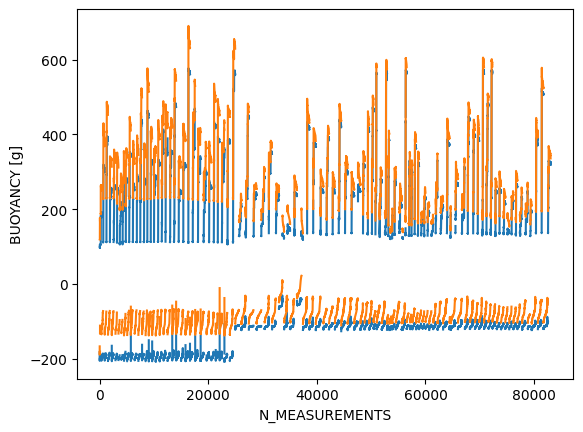

In [5]:
glider.BUOYANCY.plot()
plt.plot(seaglider_test.calc_buoyancy(glider))

In [6]:
# 5. Which parameters to optimize
whichpar = [1, 1, 1, 0, 0, 0]  # solve for hd_a, hd_b, vbdbias
#whichpar = [1, 1, 1, 0, 0, 0]  # solve for hd_a, hd_b, vbdbias

# 6. Run the regression
regressout, allwrms = seaglider_test.regress_all_vec(
    whichpar=whichpar,
    glider=glider,
    whichone=10,  # Ramsey's method
    ensmat=ensmat,
    plotflag=False,
    unstdyflag=0,
)

def renormalize_params(params, factors, direction='normalize'):
    """Renormalize parameters with given factors.

    Parameters
    ----------
    params : np.ndarray
        The parameters to transform. Expected order is
        [hd_a, hd_b, vbdbias, abs_compress, therm_expan, hd_c].
    factors : list or np.ndarray
        The factors for renormalization.
    direction : str, optional
        'normalize' to divide by factors, 'denormalize' to multiply by factors.
        Default is 'normalize'.

    Returns
    -------
    np.ndarray
        Transformed parameters.

    Raises
    ------
    ValueError
        If the direction is not 'normalize' or 'denormalize'.

    """
    if direction == 'normalize':
        return params * factors
    elif direction == 'denormalize':
        return params / factors
    else:
        raise ValueError("Direction must be 'normalize' or 'denormalize'.")

# Define renormalization factors
factors = np.array([1e3, 1e3, 1, 1e6, 1e5, 1e5])

# Create a vector of params from regressout with the same size as factors
params = np.zeros_like(factors)
params[np.array(whichpar, dtype=bool)] = regressout
# Renormalize regressout
#regressout_normalized = renormalize_params(regressout, factors, direction='normalize')
regressout_norm = renormalize_params(params, factors, direction='denormalize')

print("Optimized parameters:", regressout_norm)
print("Final WRMS:", allwrms)


🚁 Starting Glider Flight Model Parameter Optimization
Iter   0: WRMS=75.219228, hd_a=0.0036, hd_b=0.0098, vbdbias=0
Iter   1: WRMS=75.450801, hd_a=0.00378, hd_b=0.0098, vbdbias=0
Iter   2: WRMS=70.320062, hd_a=0.0036, hd_b=0.01029, vbdbias=0
Iter   3: WRMS=75.220325, hd_a=0.0036, hd_b=0.0098, vbdbias=0.00025
Iter   4: WRMS=22.349971, hd_a=0.00342, hd_b=0.01013, vbdbias=0.0001667
Iter  10: WRMS=21.493210, hd_a=0.003433, hd_b=0.01042, vbdbias=4.63e-05
Iter  20: WRMS=0.030050, hd_a=0.003288, hd_b=0.01032, vbdbias=0.0001991
Optimization terminated successfully.
         Current function value: 0.030050
         Iterations: 8
         Function evaluations: 25

🎯 Optimization Complete!

📊 Optimization Progress (25 iterations):
------------------------------------------------------------
Iter    WRMS     hd_a    hd_b   vbdbias  abs_compress  therm_expan  hd_c
   0   75.22   0.0036  0.0098         0         4e-06        2e-05 0.001
   1   75.45  0.00378  0.0098         0         4e-06        2

In [7]:
regressout_norm

array([0.00324, 0.01029, 0.00025, 0.     , 0.     , 0.     ])

In [8]:
print(regressout_norm[0],regressout_norm[1],regressout_norm[2])

0.0032400000000000003 0.010289999999999995 0.00025


Flight model calculation completed successfully!
Added variables: ['thdeg', 'umag']


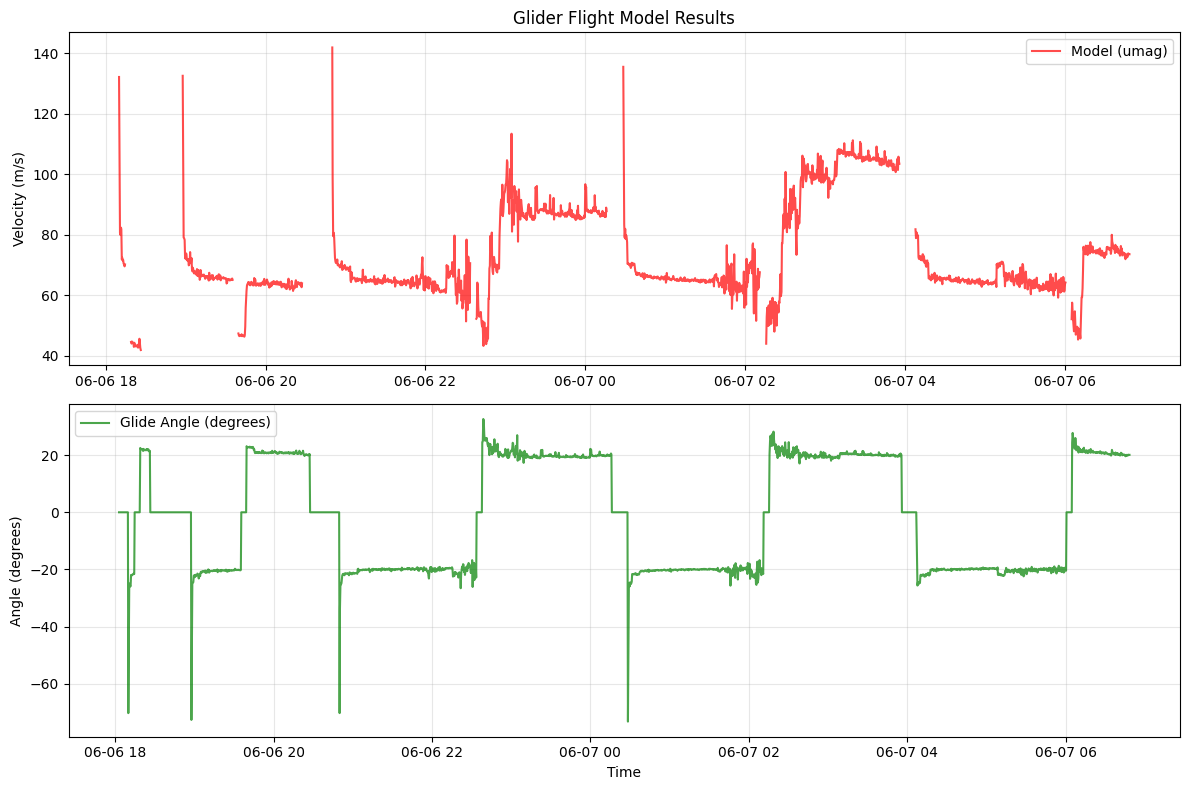

In [11]:
# 7. Apply optimized parameters and run flight model
# Update glider attributes with optimized parameters
glider.attrs.update({
    'hd_a': regressout_norm[0],
    'hd_b': regressout_norm[1], 
    'vbdbias': regressout_norm[2]
    # Keep other parameters as they were
})

# Run flight model with optimized parameters
try:
    # Calculate flight velocities using the optimized parameters
    glider_with_model = seaglider_test.flightvec_ds(
        glider, 
        xl=1.0,  # typical glider length in meters
        hd_a=glider.attrs['hd_a'],
        hd_b=glider.attrs['hd_b'],
        hd_c= 5.7e-05#glider.attrs['hd_c'] # the hd_c that was before seems to be very large!
    )
    
    print("Flight model calculation completed successfully!")
    print(f"Added variables: {list(set(glider_with_model.data_vars) - set(glider.data_vars))}")
    
    # Simple plot showing model results
    import matplotlib.pyplot as plt
    
    # Plot a subset of the data for visualization
    time_subset = slice(0, 2000)  # First 500 data points
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot vertical velocities
    if 'VERTICAL_SPEED' in glider_with_model:
        ax1.plot(glider_with_model['TIME'][time_subset], 
                glider_with_model['VERTICAL_SPEED'][time_subset], 
                'b-', label='Observed', alpha=0.7)
    
    if 'umag' in glider_with_model:
        ax1.plot(glider_with_model['TIME'][time_subset], 
                glider_with_model['umag'][time_subset], 
                'r-', label='Model (umag)', alpha=0.7)
    
    ax1.set_ylabel('Velocity (m/s)')
    ax1.set_title('Glider Flight Model Results')
    #ax1.set_ylim([25,40])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot glide angle if available
    if 'thdeg' in glider_with_model:
        ax2.plot(glider_with_model['TIME'][time_subset], 
                glider_with_model['thdeg'][time_subset], 
                'g-', label='Glide Angle (degrees)', alpha=0.7)
        ax2.set_ylabel('Angle (degrees)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Time')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error running flight model: {e}")
    print("This may be due to missing variables or incompatible data format.")
    print("Check that all required variables are present in the dataset.")

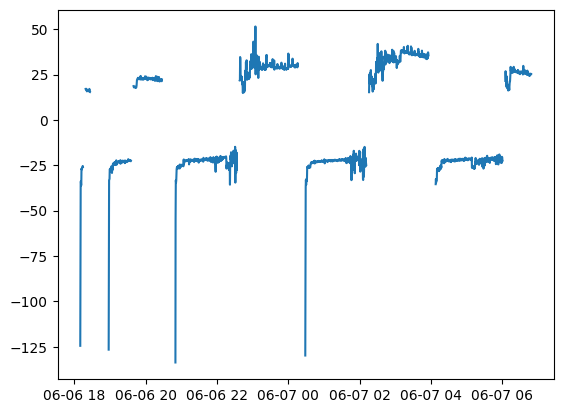

In [12]:
plt.plot(glider_with_model["TIME"][time_subset], np.sin(np.radians(glider_with_model['thdeg'][time_subset]))*glider_with_model['umag'][time_subset])

In [13]:
vbdbias = glider.attrs["vbdbias"]
volmax = 50500 #glider.attrs["volmax"]
vbd_min_cnts = glider.attrs["vbd_min_cnts"]
vbd_cnts_per_cc = glider.attrs["vbd_cnts_per_cc"]
abs_compress = glider.attrs["abs_compress"]
therm_expan = glider.attrs["therm_expan"]
temp_ref = glider.attrs["temp_ref"]
mass = glider.attrs["mass"]

print(vbdbias, volmax, vbd_min_cnts, vbd_cnts_per_cc, abs_compress, therm_expan, temp_ref, mass)

# Get data arrays
vbd = glider["VBD"].values
c_vbd = glider["C_VBD"].values
press = glider["PRES"].values if "PRES" in glider else glider["DEPTH"].values
temp = glider["TEMP"].values
salin = glider["PSAL"].values

# Get lat/lon for density calculation
if "LATITUDE" in glider and "LONGITUDE" in glider:
    lat = glider["LATITUDE"].values.mean()
    lon = glider["LONGITUDE"].values.mean()
else:
    lat, lon = 0.0, 0.0

# Calculate corrected VBD
vbdc = vbd - vbdbias

# Calculate volume with VBD, compression, and thermal expansion
vol0 = volmax + (c_vbd - vbd_min_cnts) / vbd_cnts_per_cc
vol = (vol0 + vbdc) * np.exp(
    -abs_compress * press + therm_expan * (temp - temp_ref)
)

# Calculate in-situ density
density_insitu = tools.compute_insitu_density(salin, temp, press, lat, lon)

# Calculate buoyancy in grams (following MATLAB convention)
cm2m = 0.01
kg2g = 1000
buoyancy = kg2g * (-mass + density_insitu * vol * (cm2m) ** 3)

#print(lat, lon)
#print(vbdc, vol0, vol)
print(volmax, c_vbd, vbd_min_cnts, vbd_cnts_per_cc)



0.00025 50500 390 -4.0767 4e-06 2e-05 10.0 52.277
50500 [2832. 2832. 2832. ... 2620. 2620. 2620.] 390 -4.0767


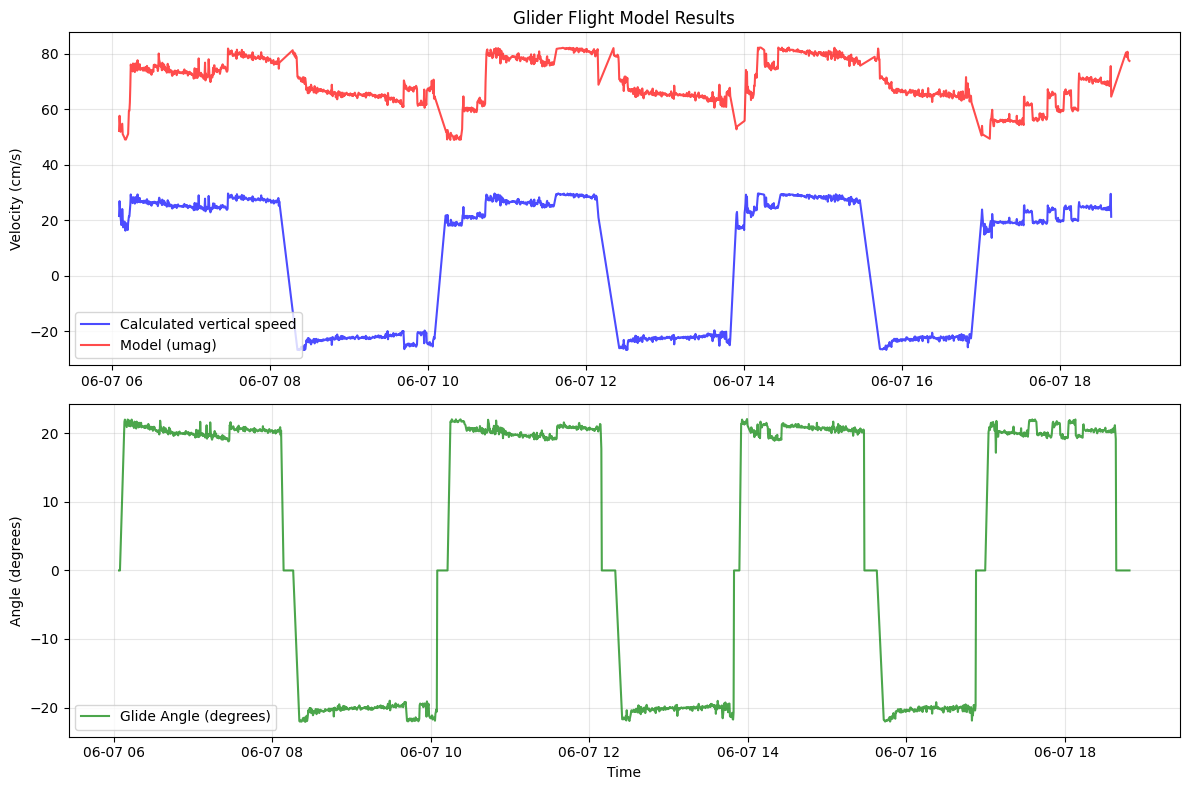

In [14]:
# Plot a subset of the data for visualization
time_subset = slice(1870, 4000) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

time = glider_with_model["TIME"][time_subset]

# --- Vertical speed: use observed if present, otherwise calculate it ---
if "VERTICAL_SPEED" in glider_with_model:
    vertical_speed = glider_with_model["VERTICAL_SPEED"][time_subset]
elif "thdeg" in glider_with_model and "umag" in glider_with_model:
    vertical_speed = (
        np.sin(np.radians(glider_with_model["thdeg"][time_subset]))
        * glider_with_model["umag"][time_subset]
    )
else:
    vertical_speed = None

# --- Plot vertical speed, keeping only the central 95% ---
if vertical_speed is not None:
    vertical_speed = np.asarray(vertical_speed)

    # Ignore NaNs when computing percentiles
    p_low, p_high = np.nanpercentile(vertical_speed, [2.5, 97.5])

    mask_vs = (vertical_speed >= p_low) & (vertical_speed <= p_high)

    label_vs = (
        "Observed vertical speed"
        if "VERTICAL_SPEED" in glider_with_model
        else "Calculated vertical speed"
    )

    ax1.plot(
        np.asarray(time)[mask_vs],
        vertical_speed[mask_vs],
        "b-",
        label=label_vs,
        alpha=0.7,
    )

# --- Plot model speed (umag), keeping only the central 95% ---
if "umag" in glider_with_model:
    umag = np.asarray(glider_with_model["umag"][time_subset])

    p_low, p_high = np.nanpercentile(umag, [2.5, 97.5])
    mask_umag = (umag >= p_low) & (umag <= p_high)

    ax1.plot(
        np.asarray(time)[mask_umag],
        umag[mask_umag],
        "r-",
        label="Model (umag)",
        alpha=0.7,
    )

ax1.set_ylabel("Velocity (cm/s)")
ax1.set_title("Glider Flight Model Results")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot glide angle, keeping only the central 95% ---
if "thdeg" in glider_with_model:
    thdeg = np.asarray(glider_with_model["thdeg"][time_subset])

    p_low, p_high = np.nanpercentile(thdeg, [2.5, 97.5])
    mask_th = (thdeg >= p_low) & (thdeg <= p_high)

    ax2.plot(
        np.asarray(time)[mask_th],
        thdeg[mask_th],
        "g-",
        label="Glide Angle (degrees)",
        alpha=0.7,
    )
    ax2.set_ylabel("Angle (degrees)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

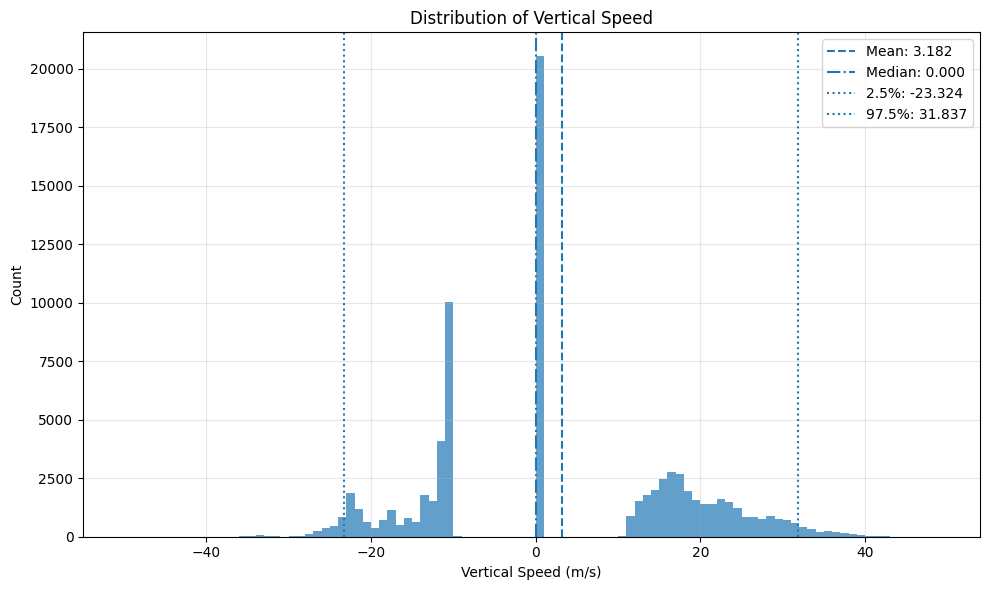

In [15]:
# --- Get vertical speed (same logic as before) ---
if "VERTICAL_SPEED" in glider_with_model:
    vs = np.asarray(glider_with_model["VERTICAL_SPEED"])
elif "thdeg" in glider_with_model and "umag" in glider_with_model:
    vs = (
        np.sin(np.radians(glider_with_model["thdeg"]))
        * glider_with_model["umag"]
    )
else:
    raise ValueError("No way to compute vertical speed")

# Remove NaNs
vs = vs[~np.isnan(vs)]

# --- Statistics ---
mean_vs = np.mean(vs)
median_vs = np.median(vs)
p_low, p_high = np.percentile(vs, [2.5, 97.5])

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.hist(vs, bins=np.arange(-50,50,1), alpha=0.7)

# Mean & median
plt.axvline(mean_vs, linestyle="--", label=f"Mean: {mean_vs:.3f}")
plt.axvline(median_vs, linestyle="-.", label=f"Median: {median_vs:.3f}")

# 95% interval
plt.axvline(p_low, linestyle=":", label=f"2.5%: {p_low:.3f}")
plt.axvline(p_high, linestyle=":", label=f"97.5%: {p_high:.3f}")

plt.xlabel("Vertical Speed (m/s)")
plt.ylabel("Count")
plt.title("Distribution of Vertical Speed")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

All: {'mean': <xarray.DataArray 'thdeg' ()> Size: 8B
array(-0.07894568), 'median': np.float64(-20.99226588004115), 'p2.5': np.float64(-26.482110839472575), 'p97.5': np.float64(36.122400822201186), 'n': 1805}
Ascent: {'mean': <xarray.DataArray 'thdeg' ()> Size: 8B
array(27.70320511), 'median': np.float64(28.287205482125824), 'p2.5': np.float64(16.459743740826), 'p97.5': np.float64(36.62340553061836), 'n': 811}
Descent: {'mean': <xarray.DataArray 'thdeg' ()> Size: 8B
array(-22.74627394), 'median': np.float64(-22.405932551338537), 'p2.5': np.float64(-26.824301269688956), 'p97.5': np.float64(-19.917765774993157), 'n': 994}


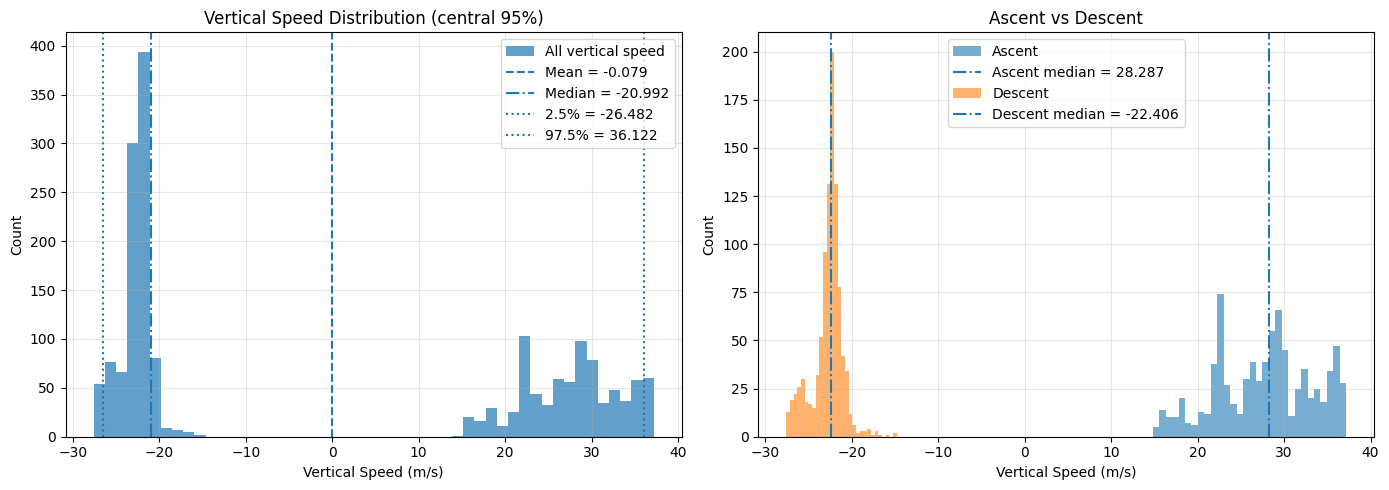

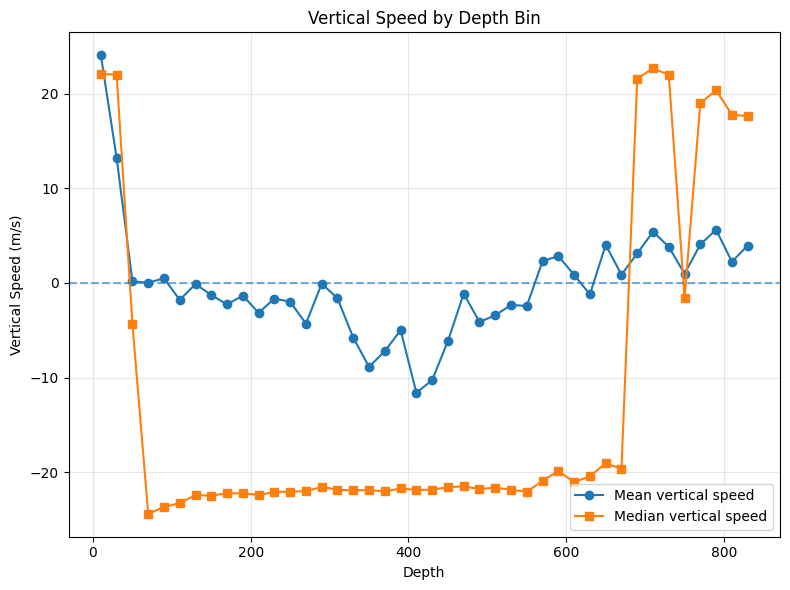

In [17]:
# -----------------------------
# 1. Build vertical speed
# -----------------------------
if "VERTICAL_SPEED" in glider_with_model:
    vs = np.asarray(glider_with_model["VERTICAL_SPEED"][time_subset])
elif "thdeg" in glider_with_model and "umag" in glider_with_model:
    vs = (
        np.sin(np.radians(glider_with_model["thdeg"][time_subset]))
        * np.asarray(glider_with_model["umag"][time_subset])
    )
else:
    raise ValueError("No way to compute vertical speed")

# Optional depth variable
depth = None
for depth_name in ["DEPTH", "depth", "PRES", "pressure"]:
    if depth_name in glider_with_model:
        depth = np.asarray(glider_with_model[depth_name][time_subset])
        break

# -----------------------------
# 2. Clean NaNs
# -----------------------------
if depth is not None:
    valid = np.isfinite(vs) & np.isfinite(depth)
    vs = vs[valid]
    depth = depth[valid]
else:
    vs = vs[np.isfinite(vs)]

# -----------------------------
# 3. Keep central 95%
# -----------------------------
p_low, p_high = np.percentile(vs, [2.5, 97.5])
mask95 = (vs >= p_low) & (vs <= p_high)

vs95 = vs[mask95]
if depth is not None:
    depth95 = depth[mask95]

# -----------------------------
# 4. Split ascent / descent
# -----------------------------
vs_ascent = vs95[vs95 > 0]
vs_descent = vs95[vs95 < 0]

# -----------------------------
# 5. Summary stats
# -----------------------------
def summarize(x):
    if len(x) == 0:
        return None
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "p2.5": np.percentile(x, 2.5),
        "p97.5": np.percentile(x, 97.5),
        "n": len(x),
    }

stats_all = summarize(vs95)
stats_ascent = summarize(vs_ascent)
stats_descent = summarize(vs_descent)

print("All:", stats_all)
print("Ascent:", stats_ascent)
print("Descent:", stats_descent)

# -----------------------------
# 6. Plot histograms
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combined histogram
axes[0].hist(vs95, bins=50, alpha=0.7, label="All vertical speed")
axes[0].axvline(stats_all["mean"], linestyle="--", label=f"Mean = {stats_all['mean']:.3f}")
axes[0].axvline(stats_all["median"], linestyle="-.", label=f"Median = {stats_all['median']:.3f}")
axes[0].axvline(stats_all["p2.5"], linestyle=":", label=f"2.5% = {stats_all['p2.5']:.3f}")
axes[0].axvline(stats_all["p97.5"], linestyle=":", label=f"97.5% = {stats_all['p97.5']:.3f}")
axes[0].set_title("Vertical Speed Distribution (central 95%)")
axes[0].set_xlabel("Vertical Speed (m/s)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ascent / descent split
if len(vs_ascent) > 0:
    axes[1].hist(vs_ascent, bins=30, alpha=0.6, label="Ascent")
    axes[1].axvline(stats_ascent["median"], linestyle="-.", label=f"Ascent median = {stats_ascent['median']:.3f}")

if len(vs_descent) > 0:
    axes[1].hist(vs_descent, bins=30, alpha=0.6, label="Descent")
    axes[1].axvline(stats_descent["median"], linestyle="-.", label=f"Descent median = {stats_descent['median']:.3f}")

axes[1].set_title("Ascent vs Descent")
axes[1].set_xlabel("Vertical Speed (m/s)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 7. Depth-binned statistics
# -----------------------------
if depth is not None:
    # Adjust bin size if needed
    depth_bins = np.arange(0, np.nanmax(depth95) + 20, 20)

    bin_centers = []
    mean_by_depth = []
    median_by_depth = []
    n_by_depth = []

    for i in range(len(depth_bins) - 1):
        d0, d1 = depth_bins[i], depth_bins[i + 1]
        m = (depth95 >= d0) & (depth95 < d1)

        if np.sum(m) > 5:
            bin_centers.append((d0 + d1) / 2)
            mean_by_depth.append(np.mean(vs95[m]))
            median_by_depth.append(np.median(vs95[m]))
            n_by_depth.append(np.sum(m))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(bin_centers, mean_by_depth, "o-", label="Mean vertical speed")
    ax.plot(bin_centers, median_by_depth, "s-", label="Median vertical speed")
    ax.axhline(0, linestyle="--", alpha=0.6)

    ax.set_xlabel("Depth")
    ax.set_ylabel("Vertical Speed (m/s)")
    ax.set_title("Vertical Speed by Depth Bin")
    ax.invert_xaxis() if False else None  # remove this line if not wanted
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

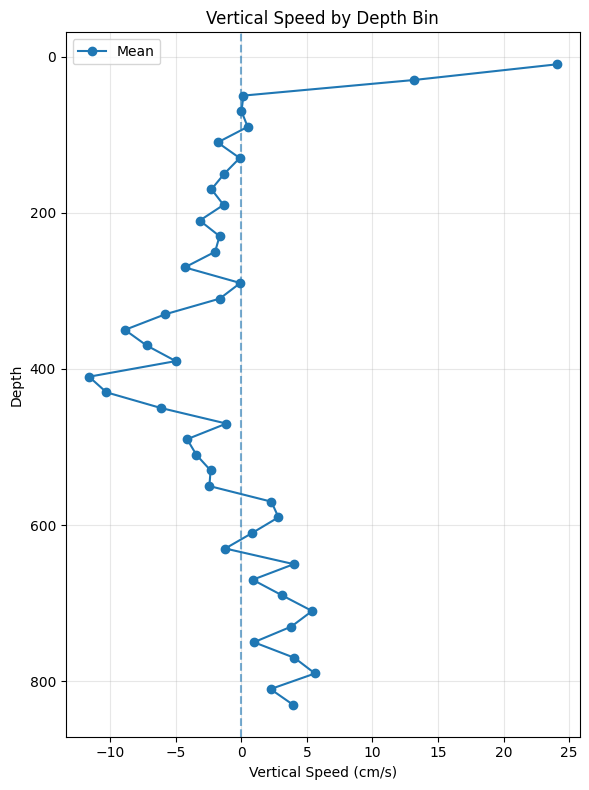

In [20]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(mean_by_depth, bin_centers, "o-", label="Mean")
#ax.plot(median_by_depth, bin_centers, "s-", label="Median")
ax.axvline(0, linestyle="--", alpha=0.6)

ax.set_xlabel("Vertical Speed (cm/s)")
ax.set_ylabel("Depth")
ax.set_title("Vertical Speed by Depth Bin")
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()